# **Eksperimen Sistem Machine Learning**

**Nama:** Muhammad Fadhil Rizki  
**Username Dicoding:** fadhilspooky  
**Dataset:** California Housing (regresi)  
**Sumber:** `sklearn.datasets.fetch_california_housing` (file mentah disimpan di `../housing_raw/housing.csv`)

Notebook ini berisi seluruh tahap eksperimen mulai dari pemuatan data, EDA, hingga preprocessing yang menghasilkan dataset siap-latih (`../housing_preprocessing/`).

# **1. Perkenalan Dataset**

California Housing Dataset memuat statistik agregat dari sensus California 1990 untuk 20.640 block group. Targetnya adalah **median nilai rumah** (dalam ratusan ribu USD) per block.

**Fitur:**
1. `MedInc` &mdash; pendapatan median rumah tangga (puluhan ribu USD)
2. `HouseAge` &mdash; usia median rumah (tahun)
3. `AveRooms` &mdash; rata-rata jumlah kamar per rumah tangga
4. `AveBedrms` &mdash; rata-rata jumlah kamar tidur per rumah tangga
5. `Population` &mdash; populasi block
6. `AveOccup` &mdash; rata-rata penghuni per rumah tangga
7. `Latitude`, `Longitude` &mdash; koordinat geografis block

**Target:** `MedHouseValue` (`MedHouseVal` di sklearn).

Kolom tambahan `TotalBedrooms_proxy` adalah turunan numerik (proxy) yang sengaja dimasukkan untuk meningkatkan kekayaan EDA. Beberapa nilai sengaja di-NaN-kan dan duplikat ditambahkan agar tahap pembersihan data benar-benar bermakna.

# **2. Import Library**

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 42
RAW_PATH = Path('../housing_raw/housing.csv')
OUT_DIR = Path('../housing_preprocessing')
OUT_DIR.mkdir(parents=True, exist_ok=True)
print('Library siap. Output dir:', OUT_DIR.resolve())

Library siap. Output dir: /Users/fadhil/Projects/SMSML_Muhammad-Fadhil-Rizki/Eksperimen_SML_Muhammad-Fadhil-Rizki/housing_preprocessing


# **3. Memuat Dataset**

In [2]:
df = pd.read_csv(RAW_PATH)
print('Shape:', df.shape)
df.head()

Shape: (20690, 10)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue,TotalBedrooms_proxy
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,129.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,1106.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,190.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,235.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,280.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20690 entries, 0 to 20689
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   MedInc               20690 non-null  float64
 1   HouseAge             20587 non-null  float64
 2   AveRooms             20690 non-null  float64
 3   AveBedrms            20629 non-null  float64
 4   Population           20690 non-null  float64
 5   AveOccup             20690 non-null  float64
 6   Latitude             20690 non-null  float64
 7   Longitude            20690 non-null  float64
 8   MedHouseValue        20690 non-null  float64
 9   TotalBedrooms_proxy  20690 non-null  float64
dtypes: float64(10)
memory usage: 1.6 MB


# **4. Exploratory Data Analysis (EDA)**

Bagian ini mengeksplorasi karakteristik data dari beberapa sudut: ringkasan statistik, kualitas data (missing & duplicate), distribusi fitur, deteksi outlier, dan keterhubungan antar fitur.

### 4.1 Statistik Deskriptif

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20690.0,3.870484,1.899343,0.499900,2.562500,3.534300,4.743925,15.000100
HouseAge,20587.0,28.647350,12.581609,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20690.0,5.429117,2.472044,0.846154,4.440930,5.229129,6.052381,141.909091
AveBedrms,20629.0,1.096772,0.474122,0.333333,1.006105,1.048780,1.099573,34.066667
Population,20690.0,1425.202658,1131.852899,3.000000,787.000000,1166.000000,1724.000000,35682.000000
AveOccup,20690.0,3.070942,10.373587,0.692308,2.429994,2.818875,3.282694,1243.333333
Latitude,20690.0,35.632090,2.136115,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20690.0,-119.569633,2.003627,-124.350000,-121.800000,-118.495000,-118.010000,-114.310000
MedHouseValue,20690.0,2.067849,1.153895,0.149990,1.194250,1.797000,2.647000,5.000010
TotalBedrooms_proxy,20690.0,537.688062,420.977501,1.000000,295.000000,435.000000,647.000000,6445.000000


### 4.2 Pemeriksaan Missing Values & Duplikasi

In [5]:
missing = df.isnull().sum().to_frame('missing_count')
missing['missing_pct'] = (missing['missing_count'] / len(df) * 100).round(3)
missing.sort_values('missing_count', ascending=False)

,missing_count,missing_pct
HouseAge,103,0.498
AveBedrms,61,0.295
MedInc,0,0.000
AveRooms,0,0.000
Population,0,0.000
AveOccup,0,0.000
Latitude,0,0.000
Longitude,0,0.000
MedHouseValue,0,0.000
TotalBedrooms_proxy,0,0.000


In [6]:
dup_count = df.duplicated().sum()
print(f'Jumlah baris duplikat: {dup_count}')

Jumlah baris duplikat: 50


### 4.3 Distribusi Fitur Numerik

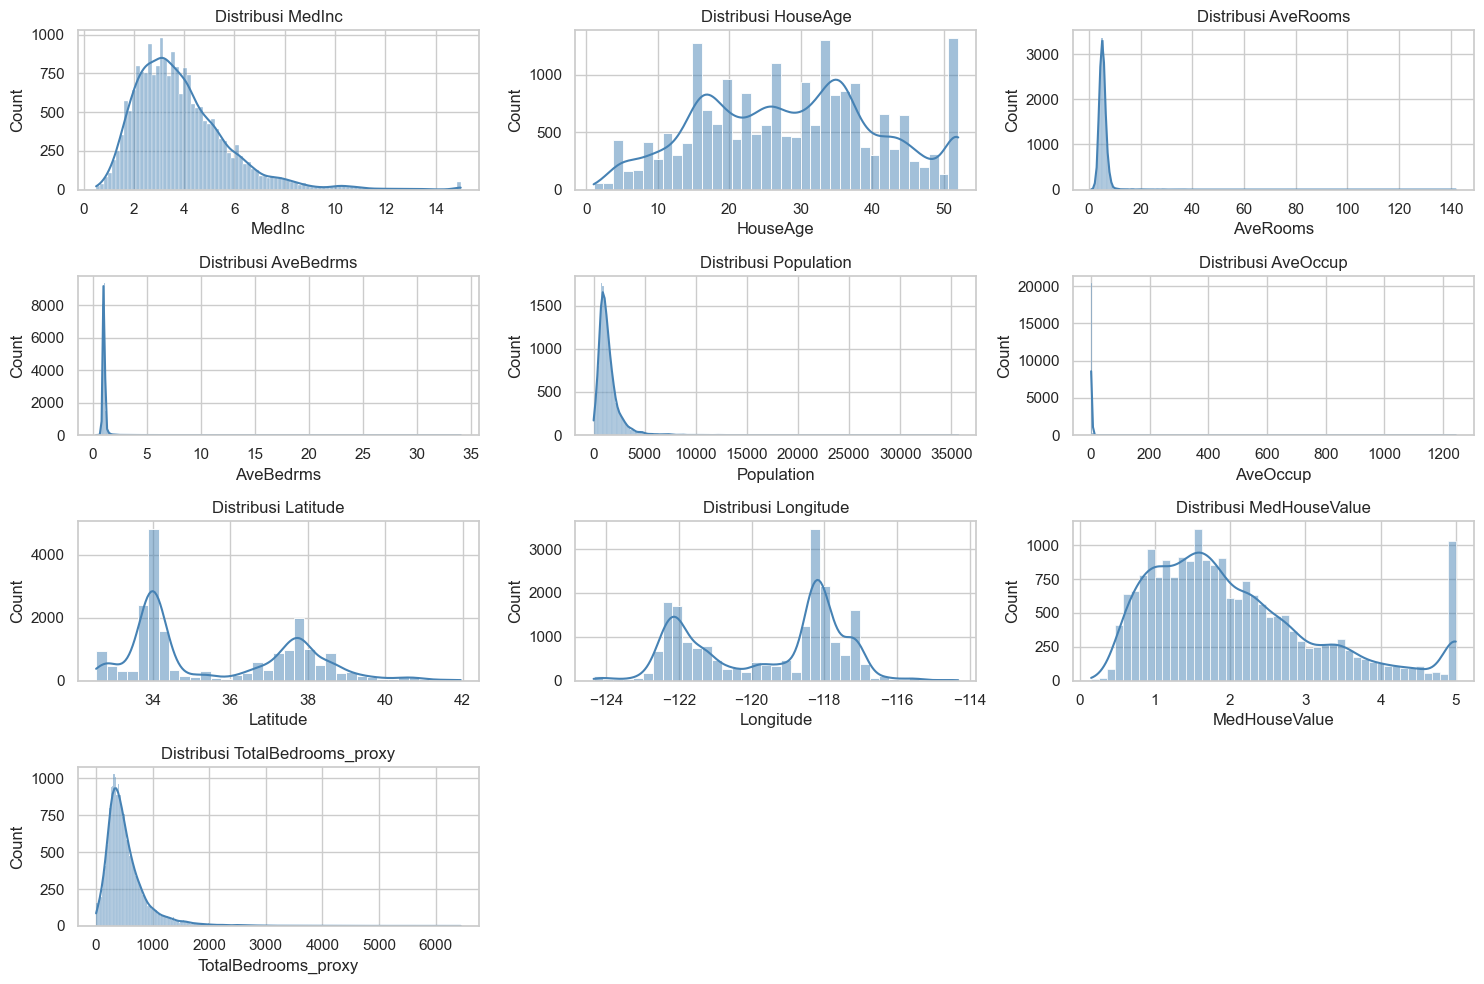

In [7]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
fig, axes = plt.subplots(nrows=(len(num_cols) + 2) // 3, ncols=3, figsize=(15, 10))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribusi {col}')
for ax in axes.flatten()[len(num_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

### 4.4 Deteksi Outlier (Boxplot)

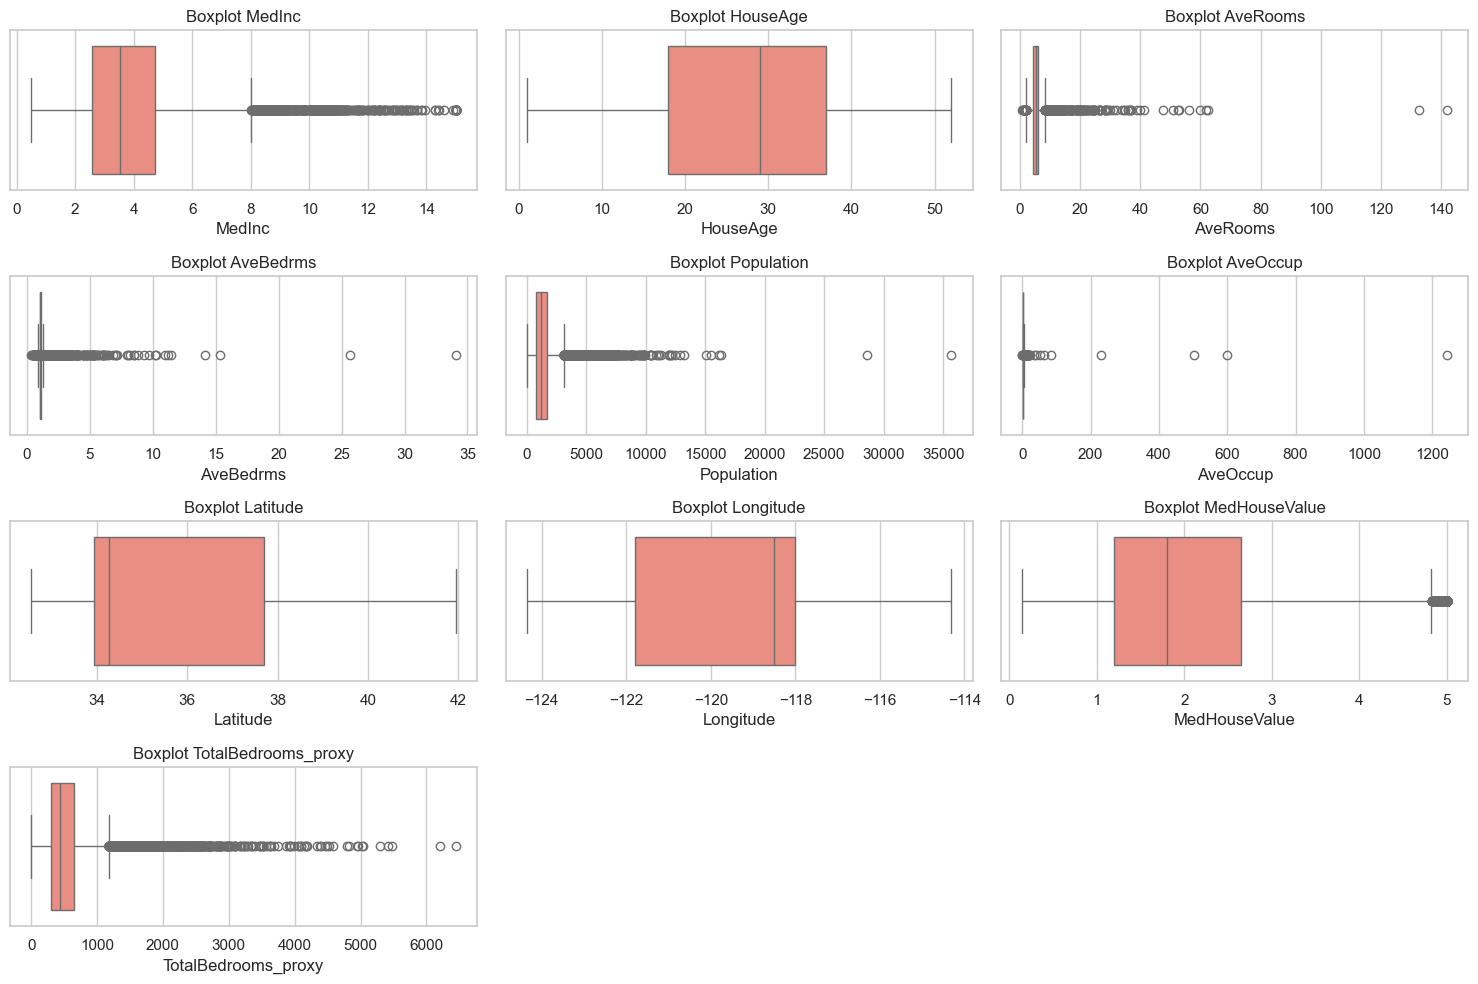

In [8]:
fig, axes = plt.subplots(nrows=(len(num_cols) + 2) // 3, ncols=3, figsize=(15, 10))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(x=df[col], ax=ax, color='salmon')
    ax.set_title(f'Boxplot {col}')
for ax in axes.flatten()[len(num_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

### 4.5 Korelasi Antar Fitur

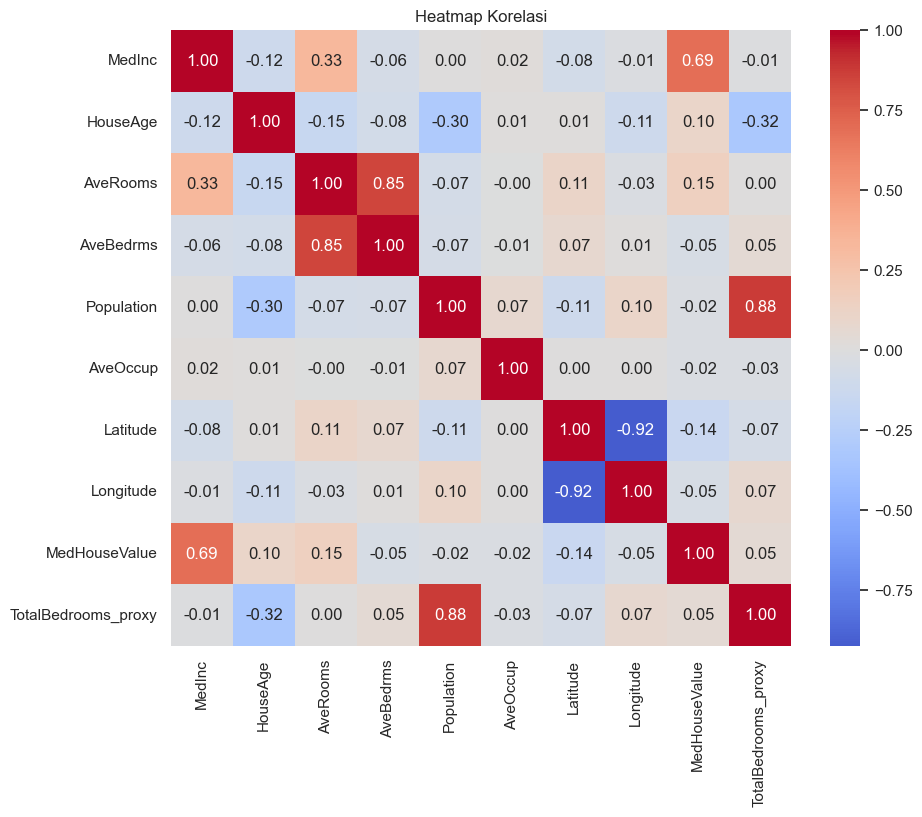

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Heatmap Korelasi')
plt.show()

In [10]:
target_corr = df.corr(numeric_only=True)['MedHouseValue'].sort_values(ascending=False)
target_corr

MedHouseValue          1.000000
MedInc                 0.687957
AveRooms               0.152075
HouseAge               0.104945
TotalBedrooms_proxy    0.050603
AveOccup              -0.023788
Population            -0.024786
Longitude             -0.046196
AveBedrms             -0.046776
Latitude              -0.144139
Name: MedHouseValue, dtype: float64

### 4.6 Analisis Geospasial (Lat/Lon vs Harga)

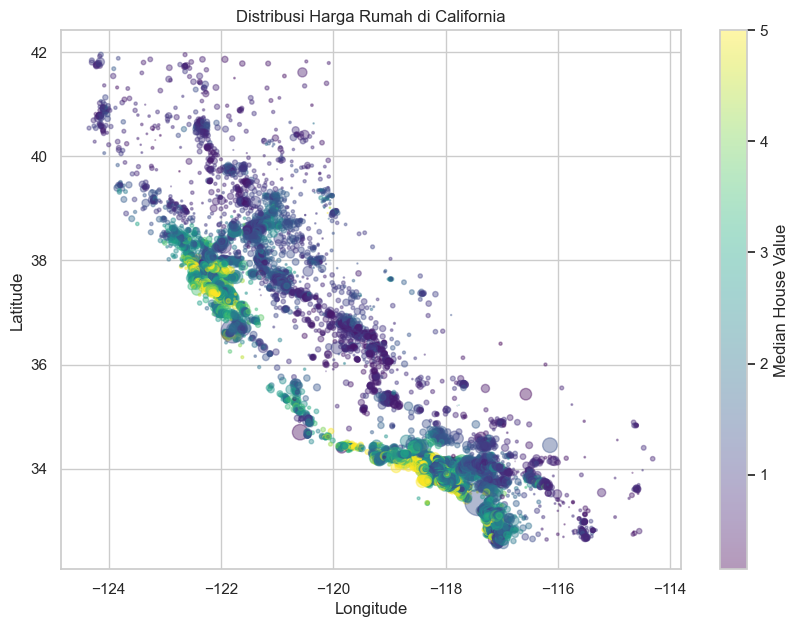

In [11]:
plt.figure(figsize=(10, 7))
sc = plt.scatter(df['Longitude'], df['Latitude'], c=df['MedHouseValue'],
                 s=df['Population'] / 100, cmap='viridis', alpha=0.4)
plt.colorbar(sc, label='Median House Value')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.title('Distribusi Harga Rumah di California')
plt.show()

**Insight EDA singkat:**
1. `MedInc` adalah prediktor terkuat target (korelasi positif tinggi).
2. Beberapa fitur (`AveRooms`, `AveBedrms`, `AveOccup`, `Population`) memiliki distribusi sangat skewed dan banyak outlier.
3. Target `MedHouseValue` ter-clip di sekitar 5.0 (cap original sklearn).
4. Pola spasial jelas: harga tinggi di pesisir (Bay Area & LA).

# **5. Data Preprocessing**

Tahapan:
1. Hapus duplikat
2. Imputasi missing values (median)
3. Cap outlier (IQR clipping) untuk fitur skewed
4. Feature engineering (rooms-per-household, bedroom-ratio, population-per-household)
5. Binning `MedInc` menjadi `IncomeCategory` untuk stratified split
6. Train-test split stratified (80/20)
7. Standardisasi (`StandardScaler`) hanya pada train, transform test
8. Simpan ke `../housing_preprocessing/`

### 5.1 Hapus Duplikat

In [12]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f'Drop {before - len(df)} duplikat. Sisa: {len(df)}')

Drop 50 duplikat. Sisa: 20640


### 5.2 Imputasi Missing Values

In [13]:
imputer = SimpleImputer(strategy='median')
feature_cols = [c for c in df.columns if c != 'MedHouseValue']
df[feature_cols] = imputer.fit_transform(df[feature_cols])
print('Sisa missing:', df.isnull().sum().sum())

Sisa missing: 0


### 5.3 Penanganan Outlier (IQR Capping)

In [14]:
def iqr_cap(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    return series.clip(lo, hi)

skewed = ['AveRooms', 'AveBedrms', 'AveOccup', 'Population', 'TotalBedrooms_proxy']
for col in skewed:
    df[col] = iqr_cap(df[col])
df[skewed].describe().T

,count,mean,std,min,25%,50%,75%,max
AveRooms,20640.0,5.304740,1.246177,2.023219,4.440716,5.229129,6.052381,8.469878
AveBedrms,20640.0,1.057891,0.080230,0.866560,1.006231,1.048780,1.099344,1.239014
AveOccup,20640.0,2.899647,0.691142,1.150961,2.429741,2.818116,3.282261,4.561041
Population,20640.0,1336.959012,765.550830,3.000000,787.000000,1166.000000,1725.000000,3132.000000
TotalBedrooms_proxy,20640.0,502.727859,287.520059,1.000000,295.000000,435.000000,647.000000,1175.000000


### 5.4 Feature Engineering

In [15]:
df['RoomsPerHousehold'] = df['AveRooms']
df['BedroomsPerRoom'] = df['AveBedrms'] / df['AveRooms']
df['PopulationPerHousehold'] = df['AveOccup']
df['IncomePerRoom'] = df['MedInc'] / (df['AveRooms'] + 1e-6)
df[['RoomsPerHousehold', 'BedroomsPerRoom', 'PopulationPerHousehold', 'IncomePerRoom']].head()

,RoomsPerHousehold,BedroomsPerRoom,PopulationPerHousehold,IncomePerRoom
0,6.984127,0.146591,2.555556,1.192017
1,6.238137,0.155797,2.109842,1.330750
2,8.288136,0.129516,2.802260,0.875637
3,5.817352,0.184458,2.547945,0.970046
4,6.281853,0.172096,2.181467,0.612271


### 5.5 Binning MedInc untuk Stratified Split

In [16]:
df['IncomeCategory'] = pd.cut(
    df['MedInc'], bins=[0, 1.5, 3.0, 4.5, 6.0, np.inf], labels=[1, 2, 3, 4, 5]
).astype(int)
df['IncomeCategory'].value_counts().sort_index()

IncomeCategory
1     822
2    6581
3    7236
4    3639
5    2362
Name: count, dtype: int64

### 5.6 Train-Test Split (Stratified) & Standardisasi

In [17]:
y = df['MedHouseValue']
X = df.drop(columns=['MedHouseValue', 'IncomeCategory'])
strat = df['IncomeCategory']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=strat
)
print('Train:', X_train.shape, '| Test:', X_test.shape)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
X_train_scaled.head()

Train: (16512, 13) | Test: (4128, 13)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,TotalBedrooms_proxy,RoomsPerHousehold,BedroomsPerRoom,PopulationPerHousehold,IncomePerRoom
12655,-0.893647,0.026885,0.143268,0.887665,1.180091,0.388198,1.347438,-0.941350,1.028308,0.143268,-0.091892,0.388198,-1.286739
15502,1.292168,-1.727419,1.296045,0.693437,0.890011,-0.399778,-1.192440,1.171782,1.230089,1.296045,-0.899056,-0.399778,0.786063
2908,-0.525434,1.223001,0.069280,-0.301064,-0.871376,-0.978787,-0.125972,0.267581,-0.665958,0.069280,-0.346009,-0.978787,-0.739820
14053,-0.865929,-0.371821,-1.136253,0.211448,-0.569536,-1.505380,-1.351474,1.221738,0.061150,-1.136253,1.174685,-1.505380,-0.580578
20496,0.325752,-0.132598,0.631747,0.699805,0.657425,0.386298,-0.635818,0.437431,0.502981,0.631747,-0.505443,0.386298,0.077355


### 5.7 Simpan Dataset Siap-Latih

In [18]:
X_train_scaled.to_csv(OUT_DIR / 'X_train.csv', index=False)
X_test_scaled.to_csv(OUT_DIR / 'X_test.csv', index=False)
y_train.to_csv(OUT_DIR / 'y_train.csv', index=False)
y_test.to_csv(OUT_DIR / 'y_test.csv', index=False)

# Versi gabungan untuk konsumsi modelling.py
train_full = X_train_scaled.copy(); train_full['MedHouseValue'] = y_train.values
test_full = X_test_scaled.copy(); test_full['MedHouseValue'] = y_test.values
train_full.to_csv(OUT_DIR / 'housing_train.csv', index=False)
test_full.to_csv(OUT_DIR / 'housing_test.csv', index=False)

print('File output:')
for f in sorted(OUT_DIR.glob('*.csv')):
    print(' -', f.name, '|', f.stat().st_size // 1024, 'KB')

File output:
 - X_test.csv | 1030 KB
 - X_train.csv | 4121 KB
 - housing_test.csv | 1054 KB
 - housing_train.csv | 4216 KB
 - y_test.csv | 23 KB
 - y_train.csv | 95 KB


## **Selesai**

Dataset siap-latih telah tersimpan di `../housing_preprocessing/`. Tahapan yang sama direplikasi secara modular di `automate_Muhammad-Fadhil-Rizki.py` dan dijalankan otomatis lewat GitHub Actions (`.github/workflows/preprocessing.yml`).